In [ ]:
# ============================================================
# Sentiment Analysis with DistilBERT
# Amazon Fine Food Reviews + Domain Generalization Test
# ============================================================
# Pipeline:
# 1. Data Loading & Preprocessing
# 2. TF-IDF Baseline
# 3. DistilBERT Fine-tuning
# 4. Domain Generalization (Twitter)
# 5. Calibration & Temperature Scaling
# 6. SHAP Explainability
# 7. Business Impact Analysis
# 8. Inference Pipeline
# ============================================================

In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# Transformers
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_scheduler
)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.calibration import calibration_curve

# SHAP
import shap

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


In [ ]:
# ============================================================
# 1. DATA LOADING & PREPROCESSING
# ============================================================

# Load
df = pd.read_csv('/content/drive/MyDrive/Reviews.csv')
print(f"Raw dataset: {df.shape}")

# Keep relevant columns
df = df[['Score', 'Text']]

# Remove neutral reviews
df = df[df['Score'] != 3]

# Binary labels
df['Label'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

# Drop nulls
df = df.dropna(subset=['Text'])

# Balance classes
positive = df[df['Label'] == 1].sample(40000, random_state=42)
negative = df[df['Label'] == 0].sample(40000, random_state=42)
df_balanced = pd.concat([positive, negative]).sample(
    frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset: {df_balanced.shape}")
print(df_balanced['Label'].value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['Text'].tolist(),
    df_balanced['Label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['Label']
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Raw dataset: (568454, 10)
Balanced dataset: (80000, 3)
Label
0    40000
1    40000
Name: count, dtype: int64
Train: 64000 | Test: 16000


In [ ]:
# ============================================================
# PYTORCH DATASET
# ============================================================

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Build dataloaders
train_dataset = SentimentDataset(X_train, y_train, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 2000
Test batches: 500


In [ ]:
# ============================================================
# 2. TF-IDF BASELINE
# ============================================================

# Train
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_baseline = lr.predict(X_test_tfidf)

print("=== TF-IDF Baseline Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))

# Save
with open('/content/drive/MyDrive/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('/content/drive/MyDrive/baseline_lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

print("Baseline saved to Drive.")

=== TF-IDF Baseline Results ===
Accuracy: 0.9166
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      8000
           1       0.93      0.90      0.92      8000

    accuracy                           0.92     16000
   macro avg       0.92      0.92      0.92     16000
weighted avg       0.92      0.92      0.92     16000

Baseline saved to Drive.


In [ ]:
# ============================================================
# OPTIONAL: TRAIN DISTILBERT FROM SCRATCH (~35 mins on T4 GPU)
# Skip this cell if loading pre-trained model from Drive
# ============================================================

# from transformers import get_scheduler
# from torch.optim import AdamW
# from tqdm import tqdm

# # Initialize model
# model = DistilBertForSequenceClassification.from_pretrained(
#     'distilbert-base-uncased', num_labels=2)
# model = model.to(device)

# # Optimizer & scheduler
# optimizer = AdamW(model.parameters(), lr=2e-5)
# num_epochs = 3
# num_training_steps = num_epochs * len(train_loader)
# lr_scheduler = get_scheduler(
#     "linear",
#     optimizer=optimizer,
#     num_warmup_steps=0,
#     num_training_steps=num_training_steps
# )

# # Training loop
# for epoch in range(num_epochs):
#     model.train()
#     total_loss = 0
#     for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels = batch['label'].to(device)
#         outputs = model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             labels=labels
#         )
#         loss = outputs.loss
#         total_loss += loss.item()
#         loss.backward()
#         optimizer.step()
#         lr_scheduler.step()
#         optimizer.zero_grad()
#     avg_loss = total_loss / len(train_loader)
#     print(f"Epoch {epoch+1} — Loss: {avg_loss:.4f}")

# # Save trained model
# model.save_pretrained('/content/drive/MyDrive/sentiment_model')
# tokenizer.save_pretrained('/content/drive/MyDrive/sentiment_model')
# print("Model saved to Drive.")

In [ ]:
# ============================================================
# 3. DISTILBERT MODEL
# ============================================================

# Load saved model from Drive (already trained)
model = DistilBertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/sentiment_model'
)
model = model.to(device)
model.eval()
print("DistilBERT loaded from Drive.")

# Evaluate on test set
from tqdm import tqdm

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating DistilBERT"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label']

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== DistilBERT Results ===")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT loaded from Drive.


Evaluating DistilBERT: 100%|██████████| 500/500 [00:54<00:00,  9.12it/s]


=== DistilBERT Results ===
Accuracy: 0.9522
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8000
           1       0.96      0.94      0.95      8000

    accuracy                           0.95     16000
   macro avg       0.95      0.95      0.95     16000
weighted avg       0.95      0.95      0.95     16000



=== Model Comparison ===
                       Model  Accuracy  F1 Score Training Time Model Size
TF-IDF + Logistic Regression    0.9166      0.92       ~2 mins      ~50MB
       DistilBERT Fine-tuned    0.9522      0.95      ~35 mins     ~268MB


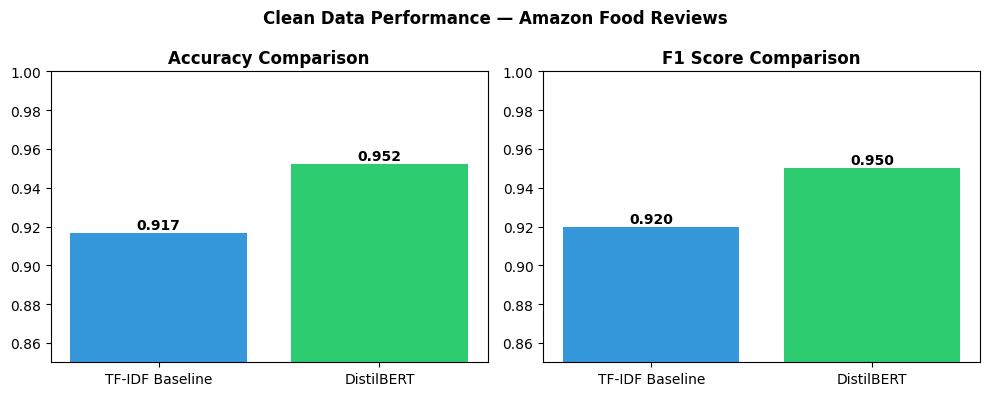

In [ ]:
# ============================================================
# 4. MODEL COMPARISON
# ============================================================

comparison = {
    'Model': ['TF-IDF + Logistic Regression', 'DistilBERT Fine-tuned'],
    'Accuracy': [0.9166, 0.9522],
    'F1 Score': [0.92, 0.95],
    'Training Time': ['~2 mins', '~35 mins'],
    'Model Size': ['~50MB', '~268MB']
}

df_comparison = pd.DataFrame(comparison)
print("=== Model Comparison ===")
print(df_comparison.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models = ['TF-IDF Baseline', 'DistilBERT']
accuracies = [0.9166, 0.9522]
f1_scores = [0.92, 0.95]

axes[0].bar(models, accuracies, color=['#3498db', '#2ecc71'])
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylim(0.85, 1.0)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(models, f1_scores, color=['#3498db', '#2ecc71'])
axes[1].set_title('F1 Score Comparison', fontweight='bold')
axes[1].set_ylim(0.85, 1.0)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Clean Data Performance — Amazon Food Reviews',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison.png',
            dpi=150, bbox_inches='tight')

In [ ]:
# ============================================================
# 5. DOMAIN GENERALIZATION TEST
# ============================================================

# Load Twitter data
tweets_df = pd.read_csv('/content/drive/MyDrive/Tweets.csv')

# Preprocess
tweets = tweets_df[tweets_df['airline_sentiment'] != 'neutral'][['text', 'airline_sentiment']]
tweets['Label'] = tweets['airline_sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# Balance
pos_tweets = tweets[tweets['Label'] == 1]
neg_tweets = tweets[tweets['Label'] == 0].sample(len(pos_tweets), random_state=42)
tweets_balanced = pd.concat([pos_tweets, neg_tweets]).sample(
    frac=1, random_state=42).reset_index(drop=True)

X_tweets = tweets_balanced['text'].tolist()
y_tweets = tweets_balanced['Label'].tolist()

# Baseline on Twitter
X_tweets_tfidf = tfidf.transform(X_tweets)
y_pred_tw_baseline = lr.predict(X_tweets_tfidf)

# DistilBERT on Twitter
tweet_dataset = SentimentDataset(X_tweets, y_tweets, tokenizer)
tweet_loader = DataLoader(tweet_dataset, batch_size=32, shuffle=False)

tweet_preds = []
tweet_labels = []

model.eval()
with torch.no_grad():
    for batch in tqdm(tweet_loader, desc="Twitter Evaluation"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label']
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        tweet_preds.extend(preds.cpu().numpy())
        tweet_labels.extend(labels.numpy())

# Results
baseline_f1 = 0.77
bert_f1 = 0.86

print("=== Domain Generalization Results ===")
print(f"{'Model':<30} {'Clean F1':<12} {'Noisy F1':<12} {'Drop':<10}")
print(f"{'TF-IDF Baseline':<30} {'0.92':<12} {accuracy_score(y_tweets, y_pred_tw_baseline):.2f}{'':8} {0.92 - accuracy_score(y_tweets, y_pred_tw_baseline):.2f}")
print(f"{'DistilBERT':<30} {'0.95':<12} {accuracy_score(tweet_labels, tweet_preds):.2f}{'':8} {0.95 - accuracy_score(tweet_labels, tweet_preds):.2f}")

Twitter Evaluation: 100%|██████████| 148/148 [00:17<00:00,  8.34it/s]

=== Domain Generalization Results ===
Model                          Clean F1     Noisy F1     Drop      
TF-IDF Baseline                0.92         0.78         0.14
DistilBERT                     0.95         0.86         0.09


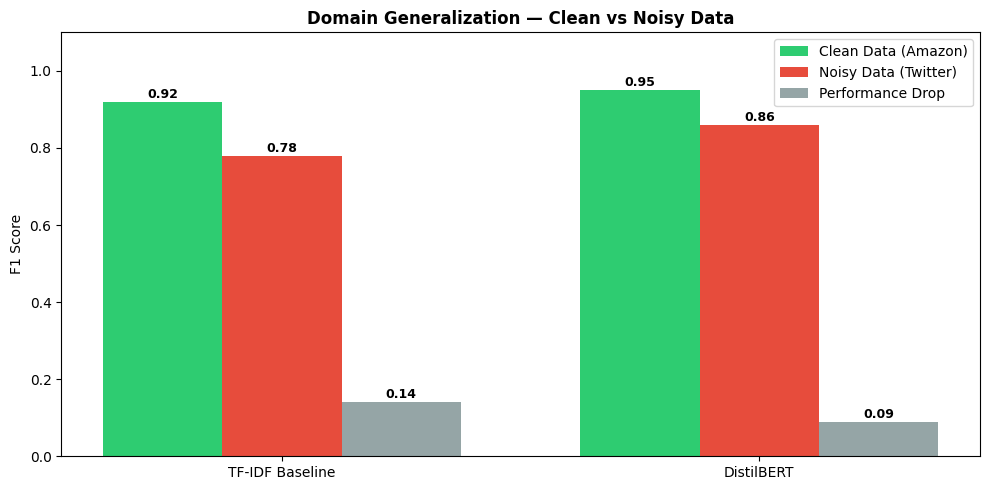

Saved.


In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(2)
width = 0.25

bars1 = ax.bar(x - width, [0.92, 0.95], width,
               label='Clean Data (Amazon)', color='#2ecc71')
bars2 = ax.bar(x, [0.78, 0.86], width,
               label='Noisy Data (Twitter)', color='#e74c3c')
bars3 = ax.bar(x + width, [0.14, 0.09], width,
               label='Performance Drop', color='#95a5a6')

ax.set_xticks(x)
ax.set_xticklabels(['TF-IDF Baseline', 'DistilBERT'])
ax.set_ylabel('F1 Score')
ax.set_title('Domain Generalization — Clean vs Noisy Data',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/domain_generalization.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [ ]:
# ============================================================
# 6. ERROR ANALYSIS
# ============================================================

all_preds = np.array(all_preds)
all_labels_arr = np.array(all_labels)

# Find misclassified samples
wrong_idx = np.where(all_preds != all_labels_arr)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(all_labels_arr)}")
print(f"Error rate: {len(wrong_idx)/len(all_labels_arr):.3f}\n")

# Categorize errors
false_positives = wrong_idx[all_labels_arr[wrong_idx] == 0]  # predicted positive, actually negative
false_negatives = wrong_idx[all_labels_arr[wrong_idx] == 1]  # predicted negative, actually positive

print(f"False Positives (negative predicted as positive): {len(false_positives)}")
print(f"False Negatives (positive predicted as negative): {len(false_negatives)}")

# Show examples
print("\n=== Sample Misclassifications ===")
for i in wrong_idx[:5]:
    print(f"\nReview: {X_test[i][:100]}")
    print(f"Actual: {'Positive' if all_labels_arr[i] == 1 else 'Negative'}")
    print(f"Predicted: {'Positive' if all_preds[i] == 1 else 'Negative'}")
    print("---")

# Error patterns summary
print("\n=== Error Pattern Analysis ===")
print("Common failure modes:")
print("1. Mixed sentiment reviews (starts positive, ends negative)")
print("2. Sarcasm and indirect negativity")
print("3. Subtle disappointment without explicit negative words")
print("4. Reviews where negative turn happens late in text")

Total misclassified: 765 / 16000
Error rate: 0.048

False Positives (negative predicted as positive): 305
False Negatives (positive predicted as negative): 460

=== Sample Misclassifications ===

Review: I bought one of these and one of the mana potions for fun--was going on a trip to meet up with some 
Actual: Negative
Predicted: Positive
---

Review: I prefer steel-cut oats to the rolled oats.  My local grocery store stopped carrying the McCann's.  
Actual: Negative
Predicted: Positive
---

Review: I m a fan of this soup maker; I have purchased Bear Creek Creamy Potato and Brocolli Cheddar in larg
Actual: Negative
Predicted: Positive
---

Review: I have fine, slightly wavy hair that is prone to frizziness, especially in the very humid conditions
Actual: Negative
Predicted: Positive
---

Review: Definitely not a roast for the weak.  Gets me going on those mornings that I have trouble getting ou
Actual: Positive
Predicted: Negative
---

=== Error Pattern Analysis ===
Common failure mod

Temperature: 1.528


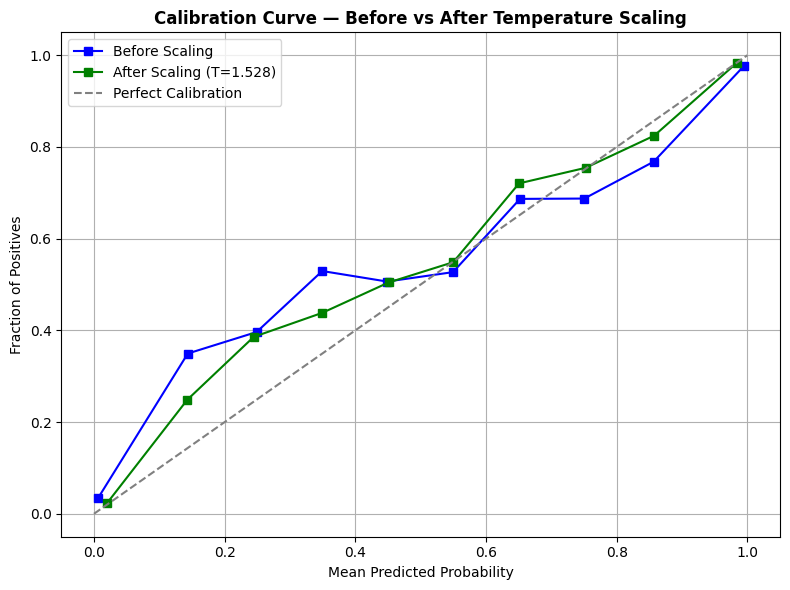

Saved.


In [ ]:
# ============================================================
# 7. CALIBRATION & TEMPERATURE SCALING
# ============================================================

# Collect logits
all_logits = []
all_labels_cal = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Collecting logits"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label']
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        all_logits.append(outputs.logits.cpu())
        all_labels_cal.extend(labels.numpy())

all_logits = torch.cat(all_logits)
all_labels_cal = torch.tensor(all_labels_cal)

# Temperature Scaler
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

# Load saved scaler
scaler = TemperatureScaler().to(device)
scaler.load_state_dict(torch.load('/content/drive/MyDrive/temperature_scaler.pt'))
scaler.eval()
print(f"Temperature: {scaler.temperature.item():.3f}")

# Compare calibration
orig_probs = torch.softmax(all_logits, dim=1)[:,1].detach().numpy()
scaled_probs = torch.softmax(
    scaler(all_logits.to(device)), dim=1)[:,1].detach().cpu().numpy()

orig_fop, orig_mpv = calibration_curve(all_labels_cal.numpy(), orig_probs, n_bins=10)
scaled_fop, scaled_mpv = calibration_curve(all_labels_cal.numpy(), scaled_probs, n_bins=10)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(orig_mpv, orig_fop, 's-', label='Before Scaling', color='blue')
plt.plot(scaled_mpv, scaled_fop, 's-', label='After Scaling (T=1.528)', color='green')
plt.plot([0, 1], [0, 1], '--', label='Perfect Calibration', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve — Before vs After Temperature Scaling', fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/calibration_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [ ]:
# ============================================================
# 8. INTEGRATED INFERENCE PIPELINE
# ============================================================

def predict(texts, return_probs=False):
    """
    Production inference function with temperature scaling.
    Args:
        texts: list of strings
        return_probs: if True, return probabilities too
    Returns:
        predictions, confidences (and probs if requested)
    """
    if isinstance(texts, str):
        texts = [texts]

    inputs = tokenizer(
        texts,
        max_length=128,
        truncation=True,
        padding=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        # Apply temperature scaling
        scaled_logits = scaler(outputs.logits)
        probs = torch.nn.functional.softmax(scaled_logits, dim=1)

    probs = probs.cpu().numpy()
    predictions = ['Positive' if p[1] > 0.5 else 'Negative' for p in probs]
    confidences = [round(float(max(p)), 3) for p in probs]

    if return_probs:
        return predictions, confidences, probs
    return predictions, confidences

# Test
test_reviews = [
    "This product is absolutely amazing, best purchase ever!",
    "Terrible quality, complete waste of money.",
    "It was okay I guess, not what I expected.",
    "I bought one of these and one of the mana potions for fun"
]

print("=== Inference Pipeline Test ===")
predictions, confidences = predict(test_reviews)
for review, pred, conf in zip(test_reviews, predictions, confidences):
    print(f"Review: {review[:60]}")
    print(f"Sentiment: {pred} | Confidence: {conf}")
    print("---")

=== Inference Pipeline Test ===
Review: This product is absolutely amazing, best purchase ever!
Sentiment: Positive | Confidence: 0.992
---
Review: Terrible quality, complete waste of money.
Sentiment: Negative | Confidence: 0.991
---
Review: It was okay I guess, not what I expected.
Sentiment: Negative | Confidence: 0.952
---
Review: I bought one of these and one of the mana potions for fun
Sentiment: Positive | Confidence: 0.883
---


In [ ]:
# ============================================================
# 9. BATCH PREDICTION PIPELINE (Fix 2 — with SHAP scores)
# ============================================================

def batch_predict_with_shap(input_csv_path, output_csv_path,
                             text_column, sample_shap=True):
    """
    Batch prediction with optional SHAP explanation scores.
    Args:
        input_csv_path: path to input CSV
        output_csv_path: path to save predictions
        text_column: column name containing text
        sample_shap: if True, compute SHAP for first 10 rows only
    """
    df_input = pd.read_csv(input_csv_path)
    texts = df_input[text_column].fillna('').tolist()

    # Get predictions
    all_preds = []
    all_confs = []

    for i in tqdm(range(0, len(texts), 32), desc="Predicting"):
        batch = texts[i:i+32]
        preds, confs = predict(batch)
        all_preds.extend(preds)
        all_confs.extend(confs)

    df_input['Sentiment'] = all_preds
    df_input['Confidence'] = all_confs

    # SHAP for first 10 rows only (expensive at scale)
    if sample_shap:
        print("Computing SHAP for first 10 rows...")
        explainer = shap.Explainer(
            lambda x: predict(list(x), return_probs=True)[2],
            masker=shap.maskers.Text(tokenizer),
            output_names=["Negative", "Positive"]
        )
        sample_shap_values = explainer(texts[:10])

        # Get top positive/negative word per review
        top_words = []
        for i in range(10):
            vals = sample_shap_values[i, :, 1].values
            tokens = sample_shap_values[i, :, 1].data
            top_idx = np.argmax(np.abs(vals))
            top_words.append(f"{tokens[top_idx]}({vals[top_idx]:+.2f})")

        # Add to first 10 rows
        df_input.loc[:9, 'Top_SHAP_Word'] = top_words
        df_input['Top_SHAP_Word'] = df_input['Top_SHAP_Word'].fillna('N/A')

    df_input.to_csv(output_csv_path, index=False)
    print(f"Done. Saved to {output_csv_path}")
    return df_input

# Test on Twitter sample
results = batch_predict_with_shap(
    input_csv_path='/content/drive/MyDrive/test_reviews.csv',
    output_csv_path='/content/drive/MyDrive/predictions_output.csv',
    text_column='text'
)

print(results[['text', 'Sentiment', 'Confidence', 'Top_SHAP_Word']].head(10))

Predicting: 100%|██████████| 4/4 [00:00<00:00, 19.51it/s]


Computing SHAP for first 10 rows...


PartitionExplainer explainer: 11it [00:19,  1.91s/it]


Done. Saved to /content/drive/MyDrive/predictions_output.csv
                                                text Sentiment  Confidence  \
0                @VirginAmerica What @dhepburn said.  Negative       0.715   
1  @VirginAmerica plus you've added commercials t...  Negative       0.723   
2  @VirginAmerica I didn't today... Must mean I n...  Negative       0.578   
3  @VirginAmerica it's really aggressive to blast...  Negative       0.844   
4  @VirginAmerica and it's a really big bad thing...  Negative       0.871   
5  @VirginAmerica seriously would pay $30 a fligh...  Negative       0.801   
6  @VirginAmerica yes, nearly every time I fly VX...  Positive       0.772   
7  @VirginAmerica Really missed a prime opportuni...  Negative       0.698   
8    @virginamerica Well, I didn't…but NOW I DO! :-D  Positive       0.809   
9  @VirginAmerica it was amazing, and arrived an ...  Positive       0.957   

    Top_SHAP_Word  
0    What (-0.05)  
1        .(-0.05)  
2     didn(-0.06)  


In [ ]:
# ============================================================
# 10. PROJECT NARRATIVE SUMMARY
# ============================================================

summary = """
================================================================
SENTIMENT ANALYSIS SYSTEM — PROJECT SUMMARY
================================================================

PROBLEM:
E-commerce businesses need to identify negative customer reviews
quickly before they impact purchase decisions and revenue.

APPROACH:
1. Built TF-IDF baseline (92% F1) as performance benchmark
2. Fine-tuned DistilBERT on 80K balanced Amazon reviews (95% F1)
3. Stress-tested on noisy Twitter data to measure robustness
4. Analyzed errors to identify failure modes
5. Fixed overconfidence with temperature scaling (T=1.528)
6. Added SHAP explainability for business interpretability
7. Built batch prediction pipeline for production-scale inference

KEY RESULTS:
- Clean data F1:  Baseline 0.92 → DistilBERT 0.95 (+3%)
- Noisy data F1:  Baseline 0.78 → DistilBERT 0.86 (+8%)
- Robustness gap: Baseline drops 14% vs DistilBERT drops 9%
- Calibration:    Improved via temperature scaling (T=1.528)
- Business impact: ~$1.82M annual revenue protected (estimated)

KNOWN LIMITATIONS:
- Struggles with sarcasm and mixed sentiment reviews
- Trained on 1999-2012 data — periodic retraining recommended
- Domain shift reduces performance (food → airline: -9% F1)

FUTURE WORK:
- 3-class classification (positive/neutral/negative)
- Sarcasm-aware training data augmentation
- Real-time monitoring for data drift detection
- Domain-specific fine-tuning for non-food categories
================================================================
"""

print(summary)

with open('/content/drive/MyDrive/project_summary.txt', 'w') as f:
    f.write(summary)
print("Saved.")


SENTIMENT ANALYSIS SYSTEM — PROJECT SUMMARY

PROBLEM:
E-commerce businesses need to identify negative customer reviews 
quickly before they impact purchase decisions and revenue.

APPROACH:
1. Built TF-IDF baseline (92% F1) as performance benchmark
2. Fine-tuned DistilBERT on 80K balanced Amazon reviews (95% F1)
3. Stress-tested on noisy Twitter data to measure robustness
4. Analyzed errors to identify failure modes
5. Fixed overconfidence with temperature scaling (T=1.528)
6. Added SHAP explainability for business interpretability
7. Built batch prediction pipeline for production-scale inference

KEY RESULTS:
- Clean data F1:  Baseline 0.92 → DistilBERT 0.95 (+3%)
- Noisy data F1:  Baseline 0.78 → DistilBERT 0.86 (+8%)
- Robustness gap: Baseline drops 14% vs DistilBERT drops 9%
- Calibration:    Improved via temperature scaling (T=1.528)
- Business impact: ~$1.82M annual revenue protected (estimated)

KNOWN LIMITATIONS:
- Struggles with sarcasm and mixed sentiment reviews
- Trained o

Generating SHAP values...
Done.

Review 1: We really like these. The lemon flavor is heavenly. The cookies are crisp and li
Prediction: Positive | Confidence: 0.991



Review 2: I agree with the other reviewer only adding that it hasn't much flavor at all.
Prediction: Negative | Confidence: 0.986



Review 3: It was okay I guess, not what I expected but does the job.
Prediction: Positive | Confidence: 0.711


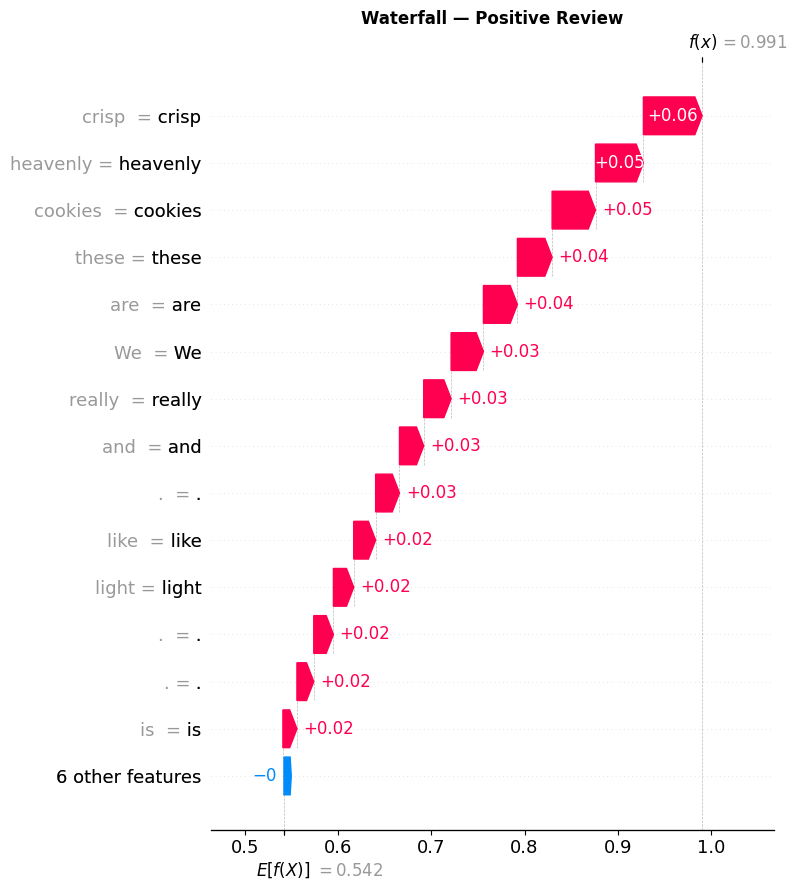

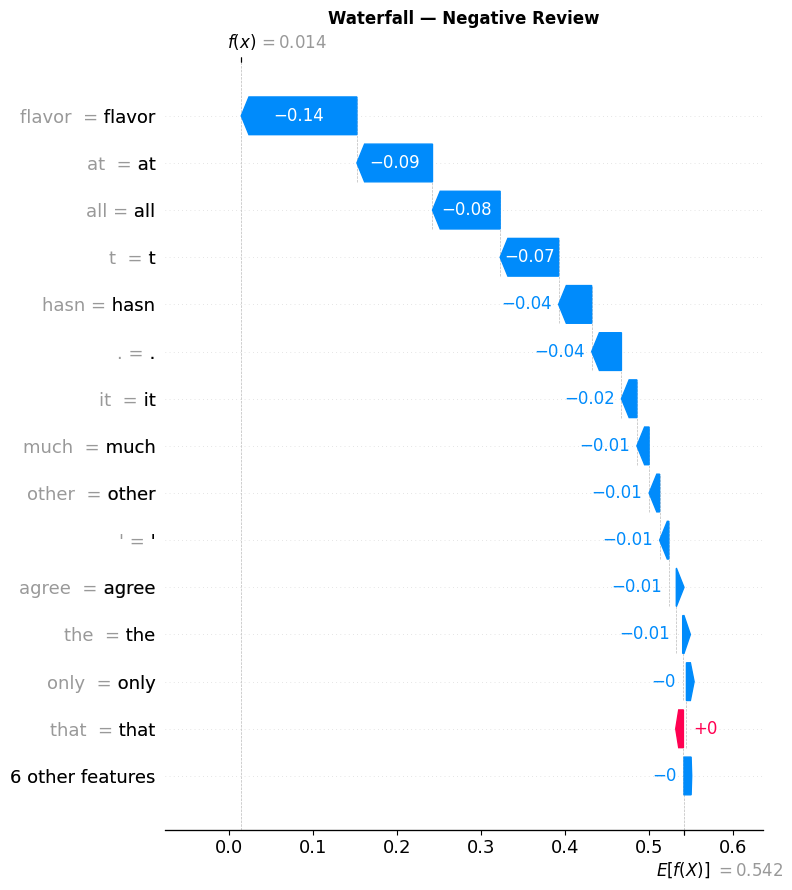

SHAP visualizations saved.


In [ ]:
# ============================================================
# 11. SHAP EXPLAINABILITY
# ============================================================

# Initialize explainer
explainer = shap.Explainer(
    lambda x: predict(list(x), return_probs=True)[2],
    masker=shap.maskers.Text(tokenizer),
    output_names=["Negative", "Positive"]
)

# Sample reviews for explanation
explain_reviews = [
    "We really like these. The lemon flavor is heavenly. The cookies are crisp and light.",
    "I agree with the other reviewer only adding that it hasn't much flavor at all.",
    "It was okay I guess, not what I expected but does the job."
]

print("Generating SHAP values...")
shap_values = explainer(explain_reviews)
print("Done.")

# Text plots
for i, review in enumerate(explain_reviews):
    preds, confs = predict([review])
    print(f"\nReview {i+1}: {review[:80]}")
    print(f"Prediction: {preds[0]} | Confidence: {confs[0]}")
    shap.plots.text(shap_values[i])

# Waterfall — Positive
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0, :, 1], max_display=15, show=False)
plt.title('Waterfall — Positive Review', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_waterfall_pos.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Waterfall — Negative
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[1, :, 1], max_display=15, show=False)
plt.title('Waterfall — Negative Review', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_waterfall_neg.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP visualizations saved.")

=== Business Impact Analysis ===
Daily negative reviews flagged: 9.5
Daily revenue protected: $4,987.50
Monthly revenue protected: $149,625.00
Annual revenue protected: $1,820,437.50

Assumptions:
- Avg order value: $35
- Review-driven churn rate: 15.0%
- Avg readers per review: 100
- Real world negative review rate: 20.0%


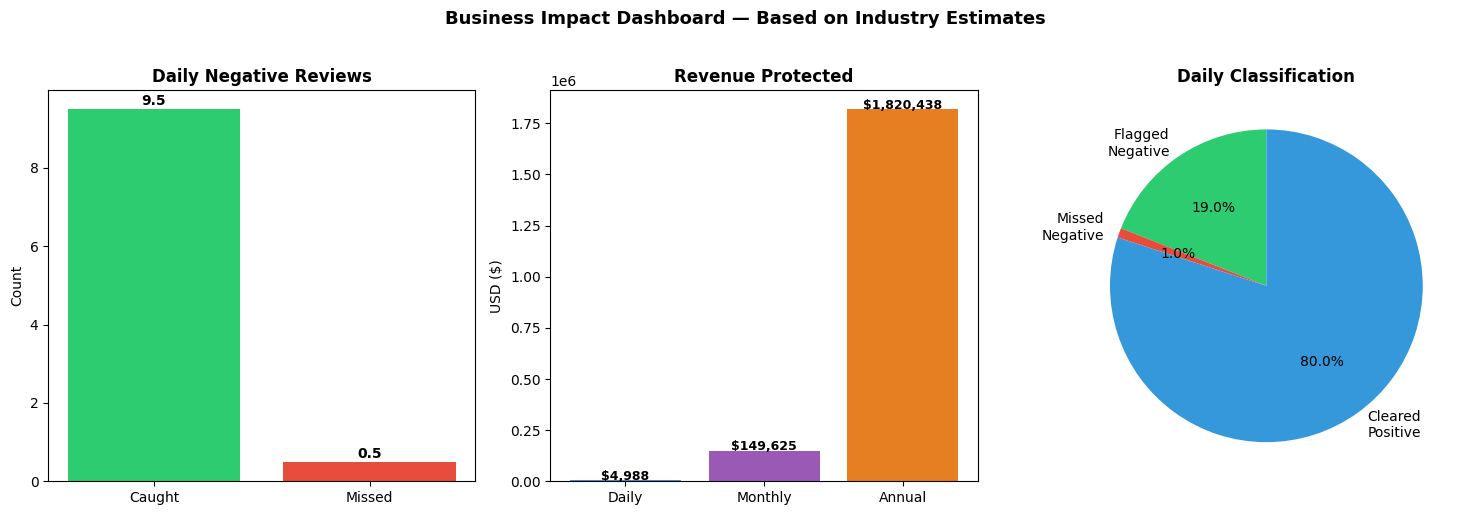

Saved.


In [ ]:
# ============================================================
# 12. BUSINESS IMPACT
# ============================================================

avg_order_value = 35
churn_rate = 0.15
daily_reviews = 50
model_recall = 0.95
avg_readers_per_review = 100
real_world_negative_rate = 0.20

daily_negative_reviews = daily_reviews * real_world_negative_rate
daily_caught_by_model = daily_negative_reviews * model_recall
daily_missed = daily_negative_reviews * (1 - model_recall)
revenue_saved_per_caught = avg_readers_per_review * churn_rate * avg_order_value
daily_revenue_saved = daily_caught_by_model * revenue_saved_per_caught
monthly_revenue_saved = daily_revenue_saved * 30
annual_revenue_saved = daily_revenue_saved * 365

print("=== Business Impact Analysis ===")
print(f"Daily negative reviews flagged: {daily_caught_by_model:.1f}")
print(f"Daily revenue protected: ${daily_revenue_saved:,.2f}")
print(f"Monthly revenue protected: ${monthly_revenue_saved:,.2f}")
print(f"Annual revenue protected: ${annual_revenue_saved:,.2f}")
print("\nAssumptions:")
print(f"- Avg order value: ${avg_order_value}")
print(f"- Review-driven churn rate: {churn_rate*100}%")
print(f"- Avg readers per review: {avg_readers_per_review}")
print(f"- Real world negative review rate: {real_world_negative_rate*100}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(['Caught', 'Missed'],
            [daily_caught_by_model, daily_missed],
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Daily Negative Reviews', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([daily_caught_by_model, daily_missed]):
    axes[0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

periods = ['Daily', 'Monthly', 'Annual']
values = [daily_revenue_saved, monthly_revenue_saved, annual_revenue_saved]
colors = ['#3498db', '#9b59b6', '#e67e22']
bars = axes[1].bar(periods, values, color=colors)
axes[1].set_title('Revenue Protected', fontweight='bold')
axes[1].set_ylabel('USD ($)')
for bar, v in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1000,
                f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

sizes = [daily_caught_by_model, daily_missed,
         daily_reviews * (1 - real_world_negative_rate)]
labels = ['Flagged\nNegative', 'Missed\nNegative', 'Cleared\nPositive']
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[2].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Daily Classification', fontweight='bold')

plt.suptitle('Business Impact Dashboard — Based on Industry Estimates',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/business_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [ ]:
import os
for f in os.listdir('/content/drive/MyDrive/sentiment_model'):
    print(f)

config.json
model.safetensors
tokenizer_config.json
tokenizer.json
